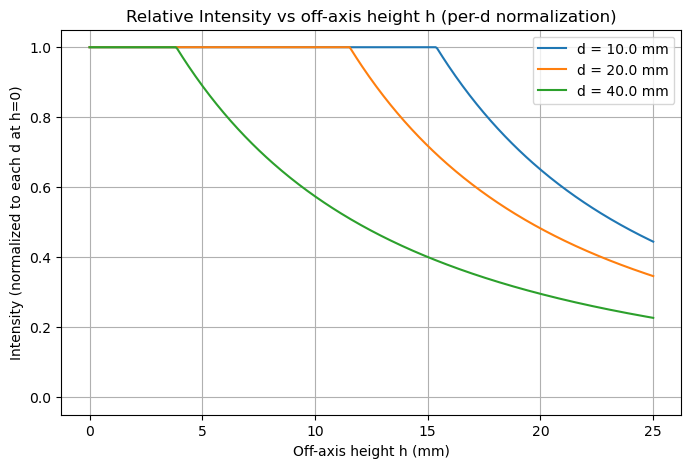

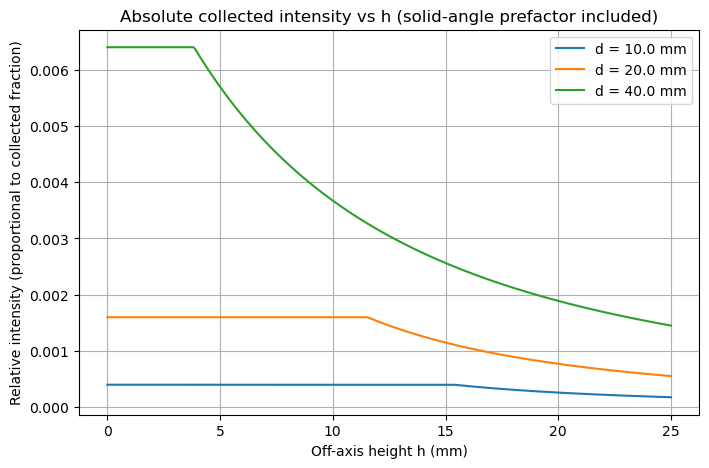

Approx. vignetting onset (first h where T_d < 1) for each d:
 d =  10.0 mm  -> h_onset ≈ 15.41 mm
 d =  20.0 mm  -> h_onset ≈ 11.59 mm
 d =  40.0 mm  -> h_onset ≈  3.88 mm


In [5]:
# ----------------------------
# Intensity vs off-axis height h
# using solid-angle approximation + vignetting factor T_d
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters (change these as needed)
# ----------------------------
f1 = 250.0     # focal length objective lens (mm)
f2 = 75.0      # focal length imaging lens (mm)
s  = f1        # distance from point to objective; often approx f1 (mm)
D2 = 50.0      # diameter of second (imaging) lens (mm)

# Choose several objective iris diameters to compare (mm)
d_list = [10.0, 20.0, 40.0]   # example objective diameters

# Range of off-axis heights h to evaluate (mm)
# choose range large enough to see vignetting onset
h_vals = np.linspace(0.0, 25.0, 400)  # from on-axis (0) to 25 mm

# ----------------------------
# Helper function: compute T_d (capped at 1)
# Using T_d = ( (D2/d)^2 ) / ( 1 + (2*h*(f1+f2))/(d*f1) )^2
# ----------------------------
def compute_Td(h, d, D2, f1, f2):
    numerator = (D2 / d)**2
    denom_term = 1.0 + (2.0 * h * (f1 + f2)) / (d * f1)
    Td_raw = numerator / (denom_term**2)
    # Transmission cannot exceed 1
    return np.minimum(Td_raw, 1.0)

# ----------------------------
# Compute normalized intensity curves
# I_norm(h;d) = ((d/2)^2 / s^2) * T_d(h)
# We'll compute both raw I_norm and also "per-d" normalized to its h=0 value
# ----------------------------
I_raw = {}      # store raw (not rescaled) normalized intensities
I_normed = {}   # store each curve normalized to its own max (h=0 typically)

for d in d_list:
    solid_pref = ( (d/2.0)**2 ) / (s**2)          # solid-angle prefactor (∝ (d/2)^2 / s^2)
    Td_array = compute_Td(h_vals, d, D2, f1, f2)  # vectorized via numpy broadcasting
    Ih = solid_pref * Td_array
    I_raw[d] = Ih
    # Normalize each curve to its maximum (value near h=0) for fair visual comparison of drop off
    max_val = np.max(Ih) if np.max(Ih) > 0 else 1.0
    I_normed[d] = Ih / max_val

# ----------------------------
# Plot 1: normalized to each curve's h=0 (shows vignetting drop vs h for each d)
# ----------------------------
plt.figure(figsize=(8,5))
for d in d_list:
    plt.plot(h_vals, I_normed[d], label=f'd = {d} mm')
plt.xlabel('Off-axis height h (mm)')
plt.ylabel('Intensity (normalized to each d at h=0)')
plt.title('Relative Intensity vs off-axis height h (per-d normalization)')
plt.grid(True)
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()

# ----------------------------
# Plot 2: absolute (not normalized across d) intensities
# This shows larger d collects more light on-axis (vertical offset between curves).
# ----------------------------
plt.figure(figsize=(8,5))
for d in d_list:
    plt.plot(h_vals, I_raw[d], label=f'd = {d} mm')
plt.xlabel('Off-axis height h (mm)')
plt.ylabel('Relative intensity (proportional to collected fraction)')
plt.title('Absolute collected intensity vs h (solid-angle prefactor included)')
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Optional: print h at which T_d drops below 1 for each d (vignetting onset)
# Using the condition Td < 1
# ----------------------------
print("Approx. vignetting onset (first h where T_d < 1) for each d:")
for d in d_list:
    Td = compute_Td(h_vals, d, D2, f1, f2)
    # locate first index where Td < 0.999 (practical drop)
    idx = np.where(Td < 0.999)[0]
    if idx.size > 0:
        print(f" d = {d:5.1f} mm  -> h_onset ≈ {h_vals[idx[0]]:5.2f} mm")
    else:
        print(f" d = {d:5.1f} mm  -> no vignetting in h range (Td≈1)")

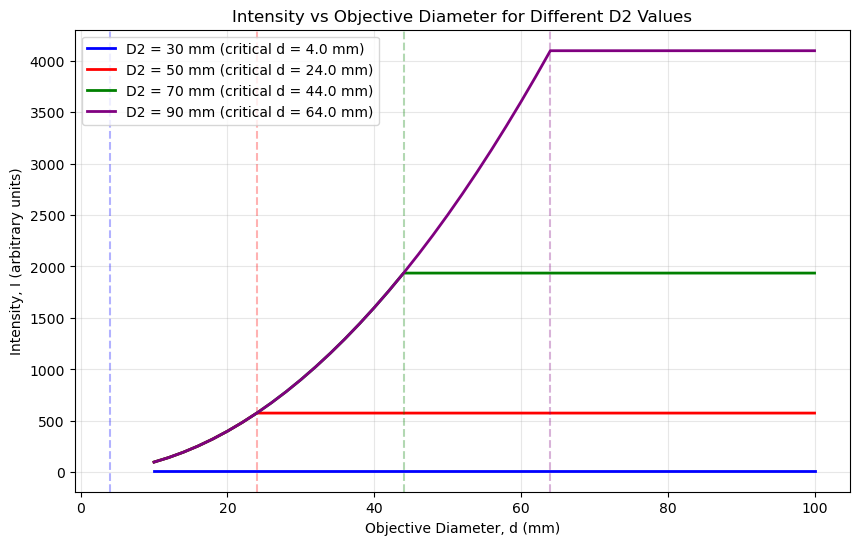

COMPARISON OF DIFFERENT D2 VALUES
System parameters:
  f1 = 250.0 mm, f2 = 75.0 mm, h = 10.0 mm

D2 (mm) | Critical d (mm) | Max Intensity
----------------------------------------
     30 |            4.0 | 16
     50 |           24.0 | 576
     70 |           44.0 | 1936
     90 |           64.0 | 4096

WHAT THE PLOT SHOWS:
1. Each colored line represents a different imaging lens diameter (D2)
2. The dashed vertical lines show where vignetting begins for each D2
3. Before the critical point: Intensity grows as d² (quadratic)
4. After the critical point: Intensity stays constant (flat line)
5. Larger D2 values:
   - Allow larger critical diameters (vignetting starts later)
   - Give higher maximum intensities


In [7]:
import matplotlib.pyplot as plt

# Optical system parameters (in mm)
f1 = 250.0  # Focal length of objective lens
f2 = 75.0   # Focal length of imaging lens
h = 10.0    # Height of object point

# Four different D2 values to test
D2_values = [30, 50, 70, 90]  # Four different imaging lens diameters

# Colors for the four lines
colors = ['blue', 'red', 'green', 'purple']

# Create the plot
plt.figure(figsize=(10, 6))

# Loop through each D2 value
for i, D2 in enumerate(D2_values):
    # Calculate the critical d for this D2 value
    # From the equation: D2/2 = d_critical/2 + (h/f1)*(f1+f2)
    critical_d = 2 * ((D2/2) - (h/f1) * (f1 + f2))
    
    # Create lists to store d and I values for this D2
    d_values = []  # Will store objective diameters
    I_values = []  # Will store calculated intensities
    
    # Loop through different objective diameters
    for d in range(10, 101, 2):  # d from 10 to 100 mm, step by 2 mm
        d_values.append(d)  # Store current d value
        
        # Calculate the right side of the inequality
        right_side = (d/2) + (h/f1) * (f1 + f2)
        
        # Check if vignetting occurs
        if (D2/2) >= right_side:
            # NO vignetting: I = d^2
            I = d ** 2
        else:
            # YES vignetting: Use intensity at critical d (constant value)
            I = critical_d ** 2
        
        I_values.append(I)  # Store calculated intensity
    
    # Plot this line with its own color
    plt.plot(d_values, I_values, color=colors[i], linewidth=2, 
             label=f'D2 = {D2} mm (critical d = {critical_d:.1f} mm)')
    
    # Add a vertical line at the critical diameter for this D2
    if critical_d > 0 and critical_d <= 100:
        plt.axvline(x=critical_d, color=colors[i], linestyle='--', alpha=0.3)

# Add labels and title
plt.xlabel('Objective Diameter, d (mm)')
plt.ylabel('Intensity, I (arbitrary units)')
plt.title('Intensity vs Objective Diameter for Different D2 Values')

# Add grid and legend
plt.grid(True, alpha=0.3)
plt.legend()

# Display the plot
plt.show()

# Print a comparison table
print("COMPARISON OF DIFFERENT D2 VALUES")
print("="*50)
print(f"System parameters:")
print(f"  f1 = {f1} mm, f2 = {f2} mm, h = {h} mm")
print()
print("D2 (mm) | Critical d (mm) | Max Intensity")
print("-" * 40)

for D2 in D2_values:
    critical_d = 2 * ((D2/2) - (h/f1) * (f1 + f2))
    max_I = critical_d ** 2 if critical_d > 0 else 0
    print(f"{D2:7} | {critical_d:14.1f} | {max_I:.0f}")

# Explanation of the plot
print("\n" + "="*50)
print("WHAT THE PLOT SHOWS:")
print("="*50)
print("1. Each colored line represents a different imaging lens diameter (D2)")
print("2. The dashed vertical lines show where vignetting begins for each D2")
print("3. Before the critical point: Intensity grows as d² (quadratic)")
print("4. After the critical point: Intensity stays constant (flat line)")
print("5. Larger D2 values:")
print("   - Allow larger critical diameters (vignetting starts later)")
print("   - Give higher maximum intensities")
print("="*50)

Critical diameter where vignetting begins: 24.00 mm


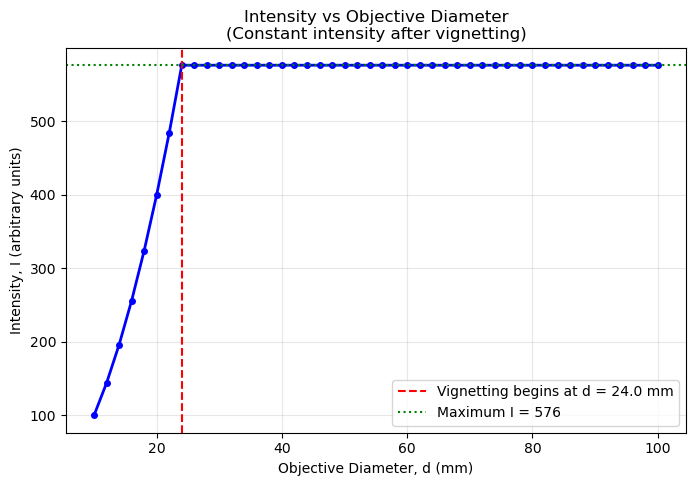


System Parameters:
Objective focal length (f1): 250.0 mm
Imaging lens focal length (f2): 75.0 mm
Imaging lens diameter (D2): 50.0 mm
Object height (h): 10.0 mm

Sample calculations:
d(mm) | Condition | Intensity
------------------------------
  20  | No vignetting | 400
  40  | Vignetting   | 576
  24  | No vignetting | 576
  60  | Vignetting   | 576
  80  | Vignetting   | 576
 100  | Vignetting   | 576


In [3]:
import matplotlib.pyplot as plt

# Optical system parameters (in mm)
f1 = 250.0  # Focal length of objective lens
f2 = 75.0   # Focal length of imaging lens
D2 = 50.0   # Diameter of imaging lens
h = 10.0    # Height of object point

# Calculate the critical d where vignetting just begins
# From the equation: D2/2 = d_critical/2 + (h/f1)*(f1+f2)
# Solve for d_critical: d_critical = 2 * [D2/2 - (h/f1)*(f1+f2)]
critical_d = 2 * ((D2/2) - (h/f1) * (f1 + f2))
print(f"Critical diameter where vignetting begins: {critical_d:.2f} mm")

# Create lists to store d values and corresponding I values
d_values = []  # Will store objective diameters
I_values = []  # Will store calculated intensities

# Loop through different objective diameters
for d in range(10, 101, 2):  # d from 10 to 100 mm, step by 2 mm
    d_values.append(d)  # Store current d value
    
    # Calculate the right side of the inequality
    # This is: d/2 + (h/f1)*(f1+f2)
    right_side = (d/2) + (h/f1) * (f1 + f2)
    
    # Check if vignetting occurs
    # Condition: D2/2 should be >= right_side for NO vignetting
    if (D2/2) >= right_side:
        # NO vignetting: I = d^2
        I = d ** 2
    else:
        # YES vignetting: Use intensity at critical d (constant value)
        I = critical_d ** 2
    
    I_values.append(I)  # Store calculated intensity

# Create the plot
plt.figure(figsize=(8, 5))

# Plot d vs I
plt.plot(d_values, I_values, 'b-', linewidth=2, marker='o', markersize=4)

# Add a vertical line at the critical diameter
plt.axvline(x=critical_d, color='red', linestyle='--', 
           label=f'Vignetting begins at d = {critical_d:.1f} mm')

# Add a horizontal line at the maximum intensity
if critical_d > 0:
    max_I = critical_d ** 2
    plt.axhline(y=max_I, color='green', linestyle=':', 
               label=f'Maximum I = {max_I:.0f}')

# Add labels and title
plt.xlabel('Objective Diameter, d (mm)')
plt.ylabel('Intensity, I (arbitrary units)')
plt.title('Intensity vs Objective Diameter\n(Constant intensity after vignetting)')

# Add grid and legend
plt.grid(True, alpha=0.3)
plt.legend()

# Display the plot
plt.show()

# Print some key values
print("\nSystem Parameters:")
print(f"Objective focal length (f1): {f1} mm")
print(f"Imaging lens focal length (f2): {f2} mm")
print(f"Imaging lens diameter (D2): {D2} mm")
print(f"Object height (h): {h} mm")
print()

print("Sample calculations:")
print("d(mm) | Condition | Intensity")
print("-" * 30)

# Show calculations for some key points
test_points = [20, 40, int(critical_d), 60, 80, 100]
for d in test_points:
    if d >= 10 and d <= 100:
        # Find the index in our lists
        idx = (d - 10) // 2
        if 0 <= idx < len(I_values):
            I = I_values[idx]
            # Calculate condition
            right_side = (d/2) + (h/f1) * (f1 + f2)
            condition = "No vignetting" if (D2/2) >= right_side else "Vignetting"
            print(f"{d:4d}  | {condition:12} | {I:.0f}")

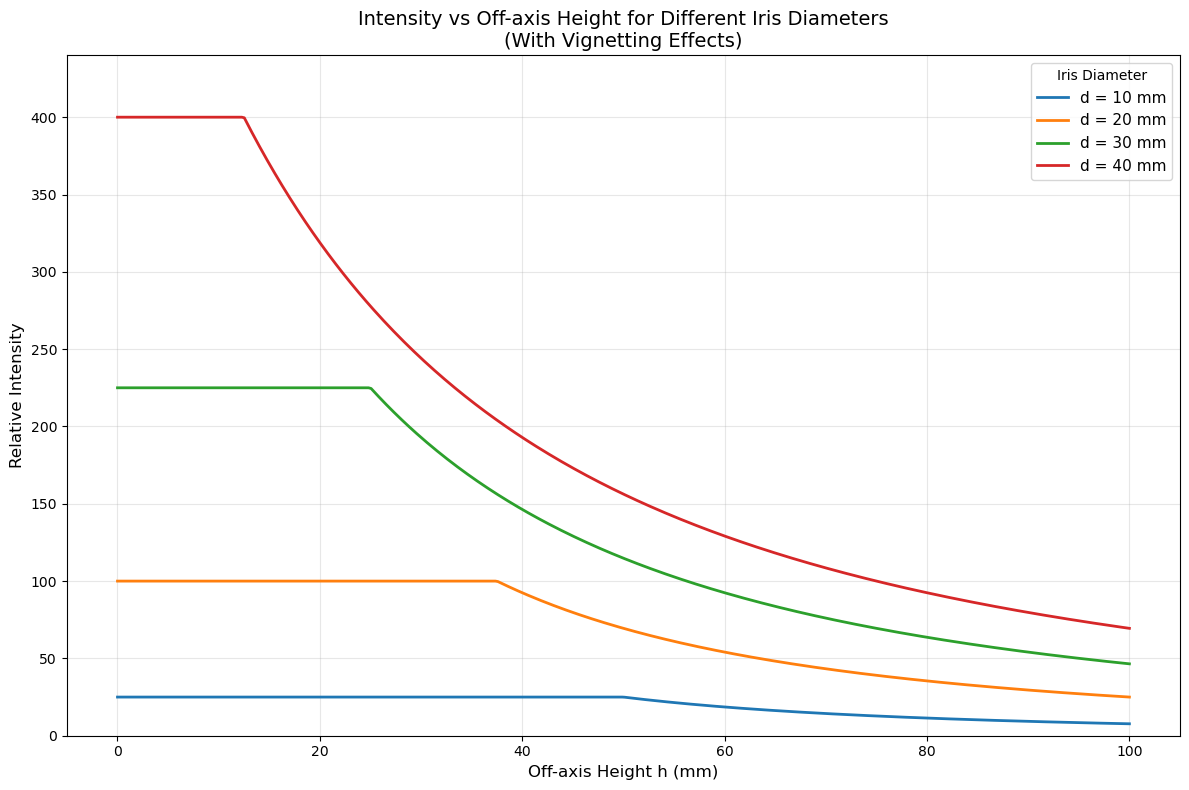

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Lens parameters (constants)
f1 = 250  
f2 = 75   
D2 = 50   # Diameter of the second lens
P = 100   # Distance between lenses

# Off-axis distance
h_values = np.linspace(0, 100, 400)  # Extended range to see more effects

# Different objective iris diameters
d_values = [10, 20, 30, 40]

plt.figure(figsize=(12, 8))

for d in d_values:
    intensity_values = []
    
    for h in h_values:
        # Calculate the required beam radius at lens 2 for full transmission
        # This considers the ray geometry from off-axis object point
        
        # Geometric approximation: the beam shift at lens 2 due to off-axis height h
        # The angular shift is approximately h/f1, and at distance P, this becomes:
        beam_shift = h * P / f1
        
        # The required radius at lens 2 to pass all light:
        # Original radius (d/2) plus the shift
        required_radius = d/2 + abs(beam_shift)
        
        # Available radius at lens 2
        available_radius = D2/2
        
        if required_radius <= available_radius:
            # No vignetting
            T_d = 1.0
        else:
            # Vignetting occurs - transmission is reduced
            # The transmitted fraction is the ratio of overlapping areas
            # For small vignetting, approximate as:
            T_d = (available_radius / required_radius) ** 2
        
        # Intensity is proportional to d^2 * transmission
        intensity = (d/2)**2 * T_d
        intensity_values.append(intensity)
    
    plt.plot(h_values, intensity_values, label=f'd = {d} mm', linewidth=2)

plt.xlabel('Off-axis Height h (mm)', fontsize=12)
plt.ylabel('Relative Intensity', fontsize=12)
plt.title('Intensity vs Off-axis Height for Different Iris Diameters\n(With Vignetting Effects)', fontsize=14)
plt.legend(title='Iris Diameter', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, max([(d/2)**2 for d in d_values]) * 1.1)
plt.tight_layout()
plt.show()